# 🚀 Entraînement Baselines - DLinear, PatchTST, PatchMixer

Entraîne les 3 modèles et compare leurs performances.

In [1]:
import sys
import os

from pathlib import Path

# Se placer à la racine du projet pour les chemins relatifs
os.chdir('..')
sys.path.append('.')

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import tqdm

# Réutiliser le code existant
from exp.exp_main import Exp_Main
from tools.metrics import metric

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Working directory: {os.getcwd()}")

Device: cpu
Working directory: /home/crulis/Documents/projects/standard-time-series-forecasting-benchmarks


## Configuration

In [2]:
class Args:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

## Entraînement des 3 modèles

In [3]:
models = [
    ('DLinear', Path("configs/linearModel.json")),
    ('PatchTST', Path("configs/patchTST.json")),
    ('PatchMixer', Path("configs/patchMixer.json"))
]
results = {}

# Créer le dossier checkpoints s'il n'existe pas
os.makedirs('checkpoints', exist_ok=True)

for model_name, config_path in models:
    print(f"\n{'='*60}")
    print(f"Entraînement {model_name}")
    print('='*60)
    
    # Config
    with open(config_path, 'r') as f:
        config = json.load(f)

    config['tracking_gradcam'] = False  # Désactiver pour rapidité
    config['epochs'] = 30  # Réduire pour tests rapides
    config['patience'] = 5

    args = Args(config)

    # Afficher config
    print(f"  - Epochs: {config['epochs']}")
    print(f"  - Batch size: {config['batch_size']}")
    print(f"  - Data: {config['data']}")
    
    # Entraîner avec code existant
    start = time.time()
    exp = Exp_Main(args, device, args.data)
    exp.training()
    
    # Tester
    preds, trues, preds_last, trues_last, _ = exp.testing()
    metrics_test = metric(trues, preds)
    metrics_val = exp.validating()
    
    elapsed = time.time() - start
    
    results[model_name] = {
        'test': metrics_test,
        'val': metrics_val,
        'time': elapsed
    }

    # Sauvegarder le modèle pour le notebook d'explicabilité
    checkpoint_path = f'checkpoints/{model_name}_baseline.pth'
    torch.save(exp.model_pred.state_dict(), checkpoint_path)
    print(f"✓ Modèle sauvegardé: {checkpoint_path}")
    
    print(f"\nTest  - MAE: {metrics_test[0]:.4f} | RMSE: {metrics_test[2]:.4f} | KGE: {metrics_test[7]:.4f}")
    print(f"Val   - MAE: {metrics_val[0]:.4f} | RMSE: {metrics_val[2]:.4f} | KGE: {metrics_val[7]:.4f}")
    print(f"Temps: {int(elapsed//60)}m{int(elapsed%60):02d}s")


Entraînement DLinear
  - Epochs: 30
  - Batch size: 16
  - Data: piezos/piezo1.csv


train ep:  73%|███████▎  | 22/30 [00:10<00:03,  2.10it/s]


Early stopping triggered at epoch 23


val batch: 100%|██████████| 68/68 [00:00<00:00, 2471.88it/s]


✓ Modèle sauvegardé: checkpoints/DLinear_baseline.pth

Test  - MAE: 0.5425 | RMSE: 0.7904 | KGE: 0.2121
Val   - MAE: 0.5838 | RMSE: 0.7593 | KGE: 0.1507
Temps: 0m11s

Entraînement PatchTST
  - Epochs: 30
  - Batch size: 16
  - Data: piezos/piezo1.csv


train ep:  63%|██████▎   | 19/30 [00:53<00:30,  2.81s/it]


KeyboardInterrupt: 

## Comparaison

In [4]:
# Tableau comparatif
df = pd.DataFrame([
    {
        'Modèle': name,
        'MAE': res['test'][0],
        'RMSE': res['test'][2],
        'KGE': res['test'][7],
        'Temps (s)': int(res['time'])
    }
    for name, res in results.items()
])

print("\n" + "="*60)
print("COMPARAISON DES MODÈLES")
print("="*60)
print(df.to_string(index=False))


COMPARAISON DES MODÈLES
 Modèle      MAE     RMSE      KGE  Temps (s)
DLinear 0.542464 0.790412 0.212062         11


KeyError: 'PatchTST'

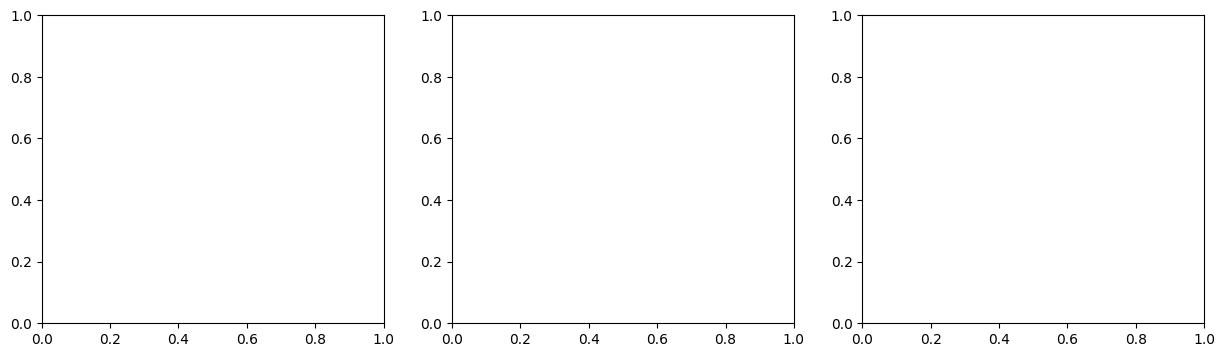

In [5]:
# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (metric, metric_idx) in enumerate([('MAE', 0), ('RMSE', 2), ('KGE', 7)]):
    ax = axes[idx]
    values = [results[m[0]]['test'][metric_idx] for m in models]
    bars = ax.bar([x[0] for x in models], values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax.set_ylabel(metric)
    ax.set_title(f'Comparaison {metric}')
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.3f}', ha='center', va='bottom')

plt.tight_layout()

# Créer le dossier figs/ s'il n'existe pas
import os
os.makedirs('figs', exist_ok=True)
plt.savefig('figs/baselines_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Sauvegarde

In [ ]:
import os
os.makedirs('results', exist_ok=True)
df.to_csv('results/baselines_comparison.csv', index=False)
print("✓ Résultats sauvegardés")